
--- Corrected Value Counts for Age_Binary ---
Age_Binary
0    184
1    123
Name: count, dtype: int64

--- Corrected Value Counts for Slope ---
Slope
1    178
0    129
Name: count, dtype: int64

--- Training Intention Model ---
Intention CV R2:   0.577 +/- 0.088
Intention Test R2: 0.618
Intention MSE:     0.534
Intention RMSE:    0.731
Intention MAE:     0.559


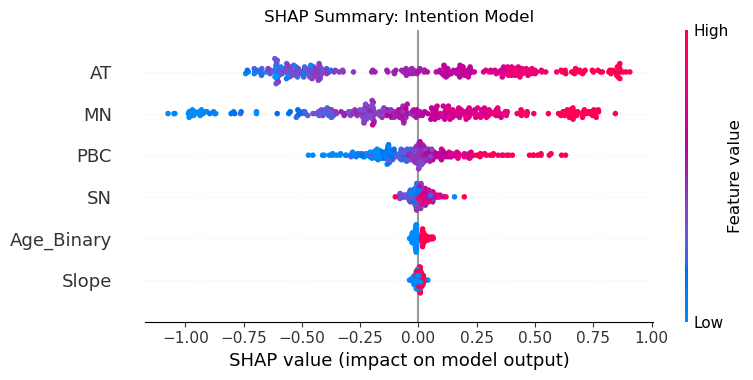

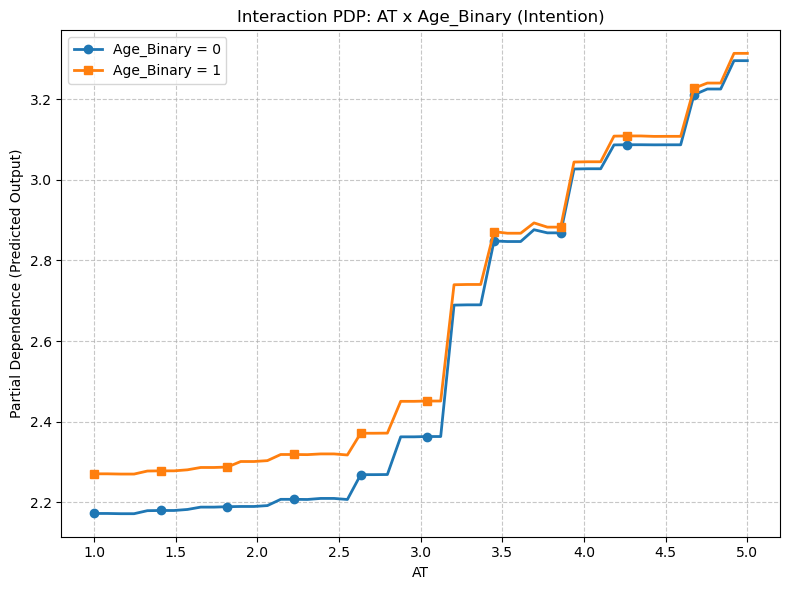

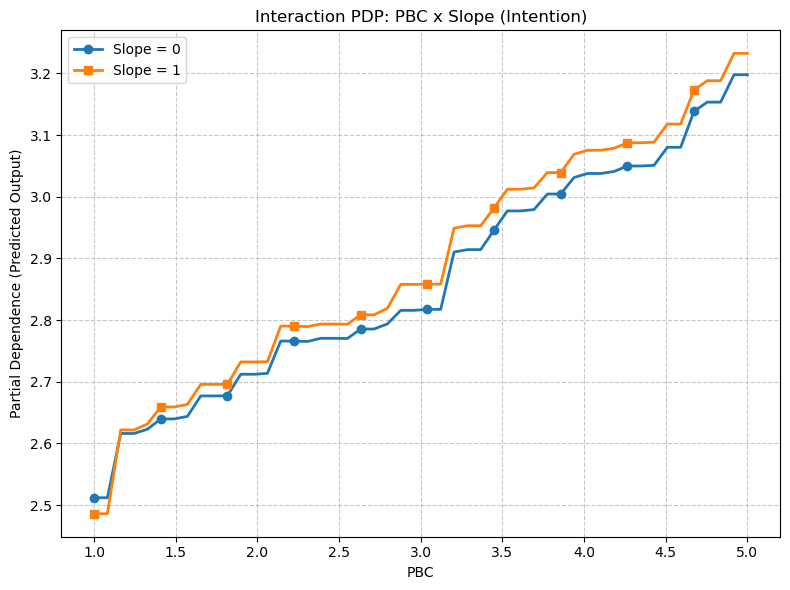


--- Training Behavior Model ---
Behavior CV R2:   0.722 +/- 0.115
Behavior Test R2: 0.761
Behavior MSE:     0.419
Behavior RMSE:    0.647
Behavior MAE:     0.459


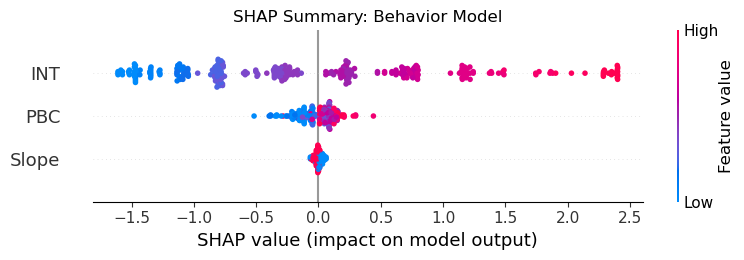

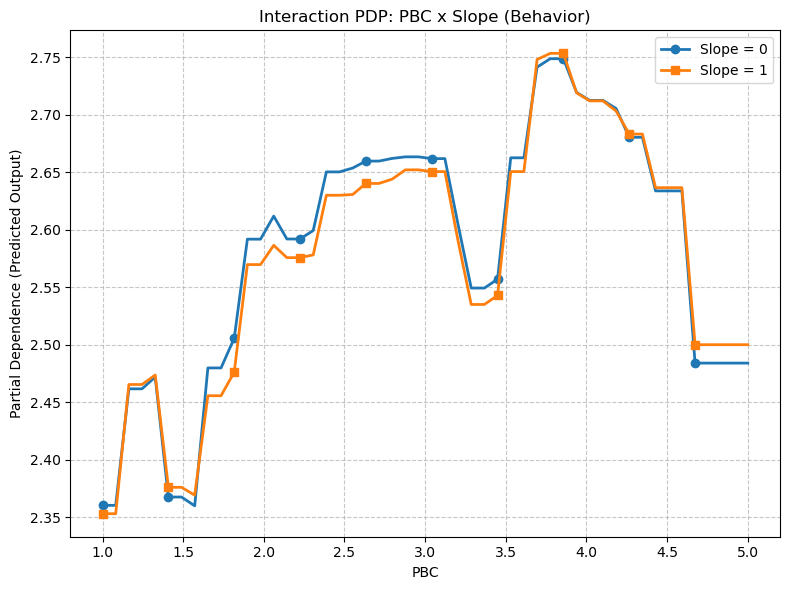


--- Mean Absolute SHAP Values (Intention Model) ---
AT            0.433850
MN            0.349536
PBC           0.134218
SN            0.029576
Age_Binary    0.019767
Slope         0.009602
dtype: float64

--- Mean Absolute SHAP Values (Behavior Model) ---
INT      0.921613
PBC      0.105286
Slope    0.015495
dtype: float64


In [2]:
"""
Machine Learning and SHAP Analysis for Behavioral Modeling
This script trains Random Forest Regressors for Intention and Behavior models,
evaluates their performance, and generates SHAP summary plots and Interaction PDPs.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap

# ==========================================
# 1. Data Loading and Cleaning
# ==========================================
# Note: Place your dataset in the same directory or update the path below
file_path = r'C:\Users\bcz\Desktop\Teh_que\TEH_ML.xlsx'
try:
    df = pd.read_excel(file_path)
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found. Please check the directory.")
    exit()

# Replace slashes (/) with dots (.) in specific columns to fix float conversions
cols_to_convert = ['AT', 'SN', 'PBC', 'INT', 'MN', 'BEH']
for col in cols_to_convert:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace('/', '.').astype(float)

# ==========================================
# 2. Data Preprocessing & Feature Engineering
# ==========================================
# --- 1. Process Age Feature ---
df['Age'] = df['Age'].astype(str).str.strip()
df['Age_Binary'] = df['Age'].apply(lambda x: 0 if '18-30' in x else 1)
# --- 2. Process Region & Slope Feature ---
df['region'] = df['region'].astype(str).str.strip()
df['region'] = pd.to_numeric(df['region'], errors='coerce')

# Define high-slope regions and create binary 'Slope' variable
high_slope_regions = [1, 2, 3, 4, 5, 6, 22]
df['Slope'] = df['region'].apply(lambda x: 1 if x in high_slope_regions else 0)

# Verify transformations
print("\n--- Corrected Value Counts for Age_Binary ---")
print(df['Age_Binary'].value_counts())

print("\n--- Corrected Value Counts for Slope ---")
print(df['Slope'].value_counts())

# Define features (X) and targets (y)
X_int = df[['AT', 'SN', 'PBC', 'MN', 'Age_Binary', 'Slope']] 
y_int = df['INT']

X_beh = df[['INT', 'PBC', 'Slope']]
y_beh = df['BEH']

# Random Forest Hyperparameter Grid
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'random_state': [42]
}

# Helper function to plot Interaction Partial Dependence (PDP)
def plot_interaction_pdp(model, X, cont_feature, bin_feature, title, filename):
    cont_values = np.linspace(X[cont_feature].min(), X[cont_feature].max(), 50)
    mean_preds_0, mean_preds_1 = [], []
    X_temp = X.copy()
    
    for val in cont_values:
        # Predictions for binary class 0
        X_temp[cont_feature] = val
        X_temp[bin_feature] = 0
        mean_preds_0.append(model.predict(X_temp).mean())
        
        # Predictions for binary class 1
        X_temp[bin_feature] = 1
        mean_preds_1.append(model.predict(X_temp).mean())
        
    plt.figure(figsize=(8, 6))
    plt.plot(cont_values, mean_preds_0, label=f'{bin_feature} = 0', linewidth=2, marker='o', markevery=5)
    plt.plot(cont_values, mean_preds_1, label=f'{bin_feature} = 1', linewidth=2, marker='s', markevery=5)
    plt.xlabel(cont_feature)
    plt.ylabel('Partial Dependence (Predicted Output)')
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show() 
    plt.close()

# ==========================================
# 3. Intention Model
# ==========================================
print("\n" + "="*40)
print("--- Training Intention Model ---")
X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(X_int, y_int, test_size=0.2, random_state=42)

# Grid Search for best hyperparameters
rf_int_grid = GridSearchCV(RandomForestRegressor(), rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_int_grid.fit(X_train_int, y_train_int)
best_rf_int = rf_int_grid.best_estimator_

# Evaluation Metrics
y_pred_int = best_rf_int.predict(X_test_int)
mse_int = mean_squared_error(y_test_int, y_pred_int)
rmse_int = np.sqrt(mse_int)
mae_int = mean_absolute_error(y_test_int, y_pred_int)
cv_scores_int = cross_val_score(best_rf_int, X_int, y_int, cv=5, scoring='r2')

print(f"Intention CV R2:   {cv_scores_int.mean():.3f} +/- {cv_scores_int.std():.3f}")
print(f"Intention Test R2: {best_rf_int.score(X_test_int, y_test_int):.3f}")
print(f"Intention MSE:     {mse_int:.3f}")
print(f"Intention RMSE:    {rmse_int:.3f}")
print(f"Intention MAE:     {mae_int:.3f}")

# SHAP Analysis (Intention)
explainer_int = shap.TreeExplainer(best_rf_int)
shap_values_int = explainer_int.shap_values(X_int)

plt.figure()
shap.summary_plot(shap_values_int, X_int, show=False)
plt.title("SHAP Summary: Intention Model")
plt.tight_layout()
plt.savefig('SHAP_Summary_Intention.png')
plt.show() 
plt.close()

# Interaction PDPs (Intention)
# 1. AT x Age_Binary
plot_interaction_pdp(best_rf_int, X_int, 'AT', 'Age_Binary', 
                     "Interaction PDP: AT x Age_Binary (Intention)", 
                     'Interaction_PDP_Intention_AT_Age.png')
# 2. PBC x Slope
plot_interaction_pdp(best_rf_int, X_int, 'PBC', 'Slope', 
                     "Interaction PDP: PBC x Slope (Intention)", 
                     'Interaction_PDP_Intention_PBC_Slope.png')

# ==========================================
# 4. Behavior Model
# ==========================================
print("\n" + "="*40)
print("--- Training Behavior Model ---")
X_train_beh, X_test_beh, y_train_beh, y_test_beh = train_test_split(X_beh, y_beh, test_size=0.2, random_state=42)

# Grid Search for best hyperparameters
rf_beh_grid = GridSearchCV(RandomForestRegressor(), rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_beh_grid.fit(X_train_beh, y_train_beh)
best_rf_beh = rf_beh_grid.best_estimator_

# Evaluation Metrics
y_pred_beh = best_rf_beh.predict(X_test_beh)
mse_beh = mean_squared_error(y_test_beh, y_pred_beh)
rmse_beh = np.sqrt(mse_beh)
mae_beh = mean_absolute_error(y_test_beh, y_pred_beh)
cv_scores_beh = cross_val_score(best_rf_beh, X_beh, y_beh, cv=5, scoring='r2')

print(f"Behavior CV R2:   {cv_scores_beh.mean():.3f} +/- {cv_scores_beh.std():.3f}")
print(f"Behavior Test R2: {best_rf_beh.score(X_test_beh, y_test_beh):.3f}")
print(f"Behavior MSE:     {mse_beh:.3f}")
print(f"Behavior RMSE:    {rmse_beh:.3f}")
print(f"Behavior MAE:     {mae_beh:.3f}")

# SHAP Analysis (Behavior)
explainer_beh = shap.TreeExplainer(best_rf_beh)
shap_values_beh = explainer_beh.shap_values(X_beh)

plt.figure()
shap.summary_plot(shap_values_beh, X_beh, show=False)
plt.title("SHAP Summary: Behavior Model")
plt.tight_layout()
plt.savefig('SHAP_Summary_Behavior.png')
plt.show() 
plt.close()

# Interaction PDP (Behavior)
plot_interaction_pdp(best_rf_beh, X_beh, 'PBC', 'Slope', 
                     "Interaction PDP: PBC x Slope (Behavior)", 
                     'Interaction_PDP_Behavior_PBC_Slope.png')

# ==========================================
# 5. Extract Mean Absolute SHAP Values
# ==========================================
print("\n" + "="*40)
print("--- Mean Absolute SHAP Values (Intention Model) ---")
# Check if shap_values is an Explanation object or an array
if hasattr(shap_values_int, 'values'):
    shap_df_int = pd.DataFrame(shap_values_int.values, columns=X_int.columns)
else:
    shap_df_int = pd.DataFrame(shap_values_int, columns=X_int.columns)
    
mean_shap_int = shap_df_int.abs().mean().sort_values(ascending=False)
print(mean_shap_int)

print("\n--- Mean Absolute SHAP Values (Behavior Model) ---")
if hasattr(shap_values_beh, 'values'):
    shap_df_beh = pd.DataFrame(shap_values_beh.values, columns=X_beh.columns)
else:
    shap_df_beh = pd.DataFrame(shap_values_beh, columns=X_beh.columns)
    
mean_shap_beh = shap_df_beh.abs().mean().sort_values(ascending=False)
print(mean_shap_beh)
